## Read housing dataset

In [15]:
import pandas as pd

# Read a Parquet file
#df_housing = pd.read_parquet("/Users/sandrarune/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/8. sem/Social dataanalyse og vis/WEEKS_ny/Sandra359.github.io/FinalProject/datasæt/DKHousingPrices.parquet", engine="fastparquet")
df_housing = pd.read_parquet("DKHousingPrices.parquet", engine="fastparquet")

df_housing
print(df_housing.columns.tolist())

['date', 'quarter', 'house_id', 'house_type', 'sales_type', 'year_build', 'purchase_price', '%_change_between_offer_and_purchase', 'no_rooms', 'sqm', 'sqm_price', 'address', 'zip_code', 'city', 'area', 'region', 'nom_interest_rate%', 'dk_ann_infl_rate%', 'yield_on_mortgage_credit_bonds%']


In [16]:
print(df_housing['area'].unique())
#map area to correct regions:
#def get_region()
#df_housing["region"] = df_housing["area"].apply(get_region)
print(df_housing["city"].nunique())


['East & mid jutland', 'Other islands', 'North jutland', 'South jutland', 'Capital, Copenhagen', 'North Zealand', 'Fyn & islands', 'Bornholm']
Categories (8, str): ['Bornholm', 'Capital, Copenhagen', 'East & mid jutland', 'Fyn & islands', 'North Zealand', 'North jutland', 'Other islands', 'South jutland']
629


In [17]:
for a in df_housing["area"].unique():
    if a == "Other islands":
        print(df_housing[df_housing["area"] == a]["city"].unique())

['Kalundborg' 'Slagelse' 'Dalmose' 'Skibby' 'Haslev' 'Orø' 'Ringsted'
 'Gedser' 'Nykøbing F' 'Dianalund' 'Jyllinge' 'Roskilde' 'Store Heddinge'
 'Herlufmagle' 'Køge' 'Gadstrup' 'Eskebjerg' 'Næstved' 'Rødvig Stevns'
 'Nykøbing Sj' 'Errindlev' 'Holbæk' 'Rødby' 'Sakskøbing' 'Nakskov'
 'Faxe Ladeplads' 'Jyderup' 'Snertinge' 'Havdrup' 'Svebølle'
 'Sjællands Odde' 'Vig' 'Dannemare' 'Fuglebjerg' 'Kirke Eskilstrup'
 'Jystrup Midtsj' 'Gørlev' 'Højby' 'Hørve' 'Bogø By' 'Fårevejle'
 'Skælskør' 'Faxe' 'Holeby' 'Kirke Såby' 'Svinninge' 'Væggerløse'
 'Idestrup' 'Store Fuglede' 'Fjenneslev' 'Strøby' 'Maribo' 'Tølløse'
 'Stege' 'Lille Skensved' 'Kirke Hyllinge' 'Rørvig' 'Fejø' 'Holmegaard'
 'Mørkøv' 'Præstø' 'Korsør' 'Nørre Asmindrup' 'Sandved' 'Sorø'
 'Jerslev Sjælland' 'Vordingborg' 'Hårlev' 'Karrebæksminde'
 'Store Merløse' 'Rønnede' 'Karise' 'Toreby L' 'Høng' 'Lejre' 'Asnæs'
 'Søllested' 'Stubbekøbing' 'Mern' 'Tappernøje' 'Borup' 'Ugerløse'
 'Askeby' 'Kettinge' 'Horslunde' 'Gislinge' 'Føllenslev' 

In [18]:
print(df_housing["area"].unique())
print(df_housing["region"].unique())
# Tjek hvad city kolonnen indeholder
print(df_housing["city"].unique())

['East & mid jutland', 'Other islands', 'North jutland', 'South jutland', 'Capital, Copenhagen', 'North Zealand', 'Fyn & islands', 'Bornholm']
Categories (8, str): ['Bornholm', 'Capital, Copenhagen', 'East & mid jutland', 'Fyn & islands', 'North Zealand', 'North jutland', 'Other islands', 'South jutland']
['Jutland', 'Zealand', 'Fyn & islands', 'Bornholm']
Categories (4, str): ['Bornholm', 'Fyn & islands', 'Jutland', 'Zealand']
['Hinnerup' 'Kalundborg' 'Gistrup' 'Aarhus C' 'Silkeborg' 'Odder'
 'Jelling' 'Hejls' 'Slagelse' 'Janderup Vestj' 'Børkop' 'Skovlunde'
 'Solrød Strand' 'København SV' 'Holstebro' 'Frederiksberg C' 'Fredericia'
 'Græsted' 'Dalmose' 'Skive' 'Brønshøj' 'Tikøb' 'Helsingør' 'Hillerød'
 'Skibby' 'Gram' 'Ringkøbing' 'Haslev' 'Orø' 'Otterup' 'Allerød'
 'Ringsted' 'Løgstør' 'Charlottenlund' 'Ballerup' 'Ebeltoft' 'Skørping'
 'Jordrup' 'Glostrup' 'Værløse' 'Bindslev' 'Vejen' 'Rødovre' 'Gedser'
 'Aalborg' 'Nykøbing F' 'Dianalund' 'Jyllinge' 'Odense S' 'Roskilde'
 'Rudkøbing'

### Map zip_code to municipality

In [19]:
# DAWA API - Danmarks officielle adresseregister
import requests

def zip_to_municipality(zip_code):
    url = f"https://api.dataforsyningen.dk/postnumre/{zip_code}" #get the municipality name from the zip code using the DAWA API
    r = requests.get(url)
    if r.status_code == 200: #if successful, return the municipality name
        data = r.json()
        return data["kommuner"][0]["navn"] 
    return None

# Lav kun ét kald per unikt zip_code
unique_zips = df_housing["zip_code"].unique()

zip_to_muni = {}
for zip_code in unique_zips:
    zip_to_muni[zip_code] = zip_to_municipality(zip_code)


In [20]:
print(len(zip_to_muni))
#find unikke kommuner i zip to muni
unique_munis = set(zip_to_muni.values())
print(unique_munis)


941
{'Varde', 'Kerteminde', 'Skanderborg', 'Køge', 'Hørsholm', 'Helsingør', 'Norddjurs', 'Hedensted', 'Dragør', 'Faxe', 'Aarhus', 'Rudersdal', 'Allerød', 'Høje-Taastrup', 'Fredericia', 'Randers', 'Solrød', 'Egedal', 'Hillerød', 'Svendborg', 'Bornholm', 'Lolland', 'Ringsted', 'Lejre', 'Lemvig', 'Gentofte', 'Ballerup', 'Vordingborg', 'Roskilde', 'København', 'Langeland', 'Nordfyns', 'Esbjerg', 'Brønderslev', 'Fredensborg', 'Odense', 'Struer', 'Favrskov', 'Horsens', 'Frederikshavn', 'Ikast-Brande', 'Gladsaxe', 'Læsø', 'Sønderborg', 'Holbæk', 'Odsherred', 'Frederiksberg', 'Rebild', 'Billund', 'Stevns', 'Vejen', 'Kalundborg', 'Guldborgsund', 'Nyborg', 'Haderslev', 'Odder', 'Morsø', 'Aalborg', 'Kolding', 'Middelfart', 'Vejle', 'Thisted', 'Tønder', 'Hjørring', 'Brøndby', 'Silkeborg', 'Greve', 'Syddjurs', 'Skive', 'Ringkøbing-Skjern', 'Slagelse', 'Aabenraa', 'Furesø', 'Viborg', 'Fanø', 'Vesthimmerlands', 'Næstved', 'Ærø', 'Herning', 'Assens', 'Albertslund', 'Halsnæs', 'Faaborg-Midtfyn', 'Valle

## Check interest rate

In [21]:
interest_rate = df_housing['nom_interest_rate%']
print(interest_rate)
print(interest_rate.value_counts())
print(interest_rate.nunique())

0          3.1
1          3.1
2          3.1
3          3.1
4          3.1
          ... 
1507903    9.5
1507904    9.5
1507905    9.5
1507906    9.5
1507907    9.5
Name: nom_interest_rate%, Length: 1507908, dtype: float32
nom_interest_rate%
0.00    698458
2.00    111567
3.25     78008
3.60     67811
0.75     66791
4.00     50269
3.50     45711
3.75     32438
2.75     31604
1.00     25702
9.50     25569
4.25     24706
2.60     22254
2.50     21545
5.00     20219
3.10     19239
1.75     18699
3.35     17153
3.00     16534
0.65     15305
4.75     15145
4.50     13710
2.25     11566
6.00     11534
0.25      9571
1.50      8282
1.20      7733
5.50      5894
7.75      5174
8.25      4959
6.25      4758
Name: count, dtype: int64
31


In [22]:
df_housing1 = df_housing.copy()
df_housing1 = df_housing1[df_housing1["date"] >= "2008-01-01"]
df_housing1 = df_housing1[df_housing1["date"] <= "2008-12-31"]
print(min(df_housing1["date"]))
print(max(df_housing1["date"]))

2008-01-01 00:00:00
2008-12-31 00:00:00


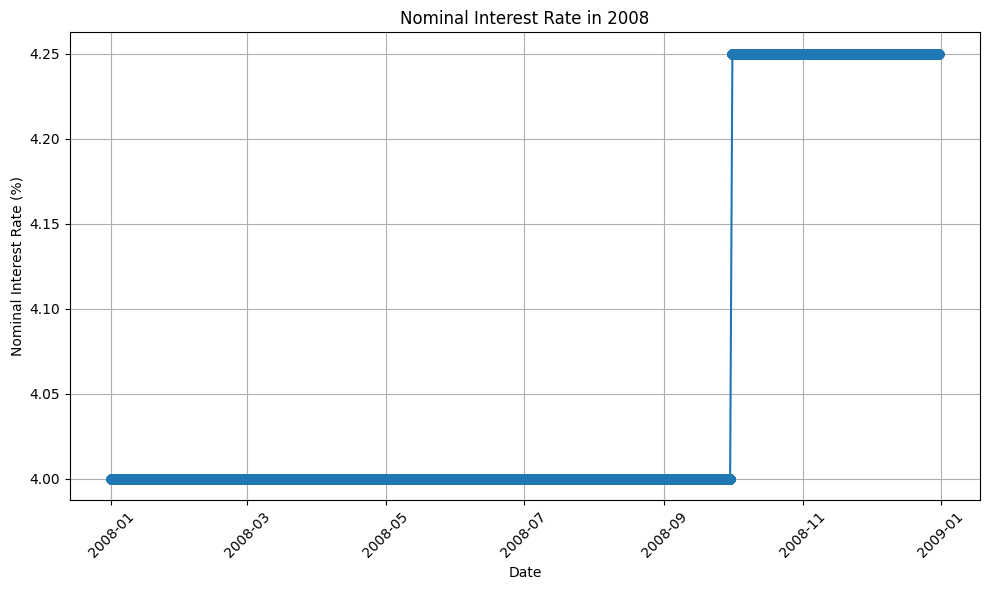

In [23]:

df_housing1["nom_interest_rate%"].value_counts()
#plot nom_interest_rate% as a function of time in 2008 
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(df_housing1["date"], df_housing1["nom_interest_rate%"], marker='o', linestyle='-')
plt.title("Nominal Interest Rate in 2008")
plt.xlabel("Date")
plt.ylabel("Nominal Interest Rate (%)")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [24]:
#map nom_interest_rates to cityes 
df_housing1.groupby("city")["nom_interest_rate%"].mean()

city
               4.125000
Aabenraa       4.043182
Aabybro        4.039855
Aakirkeby      4.044445
Aalborg        4.051961
                 ...   
Ã
lbæk         4.067073
Ã
lsgårde      4.043478
Ã
rre          4.036765
Ã
rslev        4.056962
Ãrøskøbing    4.035714
Name: nom_interest_rate%, Length: 599, dtype: float32

In [25]:
# Se om renten varierer over tid
df_housing1[["date", "nom_interest_rate%"]].drop_duplicates().sort_values("date")

,date,nom_interest_rate%
1027951,2008-01-01,4.00
1027862,2008-01-02,4.00
1027770,2008-01-03,4.00
1027743,2008-01-04,4.00
1027709,2008-01-05,4.00
...,...,...
992466,2008-12-27,4.25
992395,2008-12-28,4.25
992342,2008-12-29,4.25
992300,2008-12-30,4.25


In [26]:
df_housing[["date", "nom_interest_rate%"]].drop_duplicates().sort_values("nom_interest_rate%").drop_duplicates("nom_interest_rate%").sort_values("date")

,date,nom_interest_rate%
1497741,1992-07-07,9.50
1479403,1993-08-28,7.75
1477121,1993-10-02,8.25
1470759,1994-02-01,6.25
1467423,1994-04-01,5.50
1448992,1995-02-26,5.00
1438012,1995-08-20,6.00
1426743,1996-02-27,4.25
1376615,1998-02-21,3.50
1327297,1999-12-11,2.75


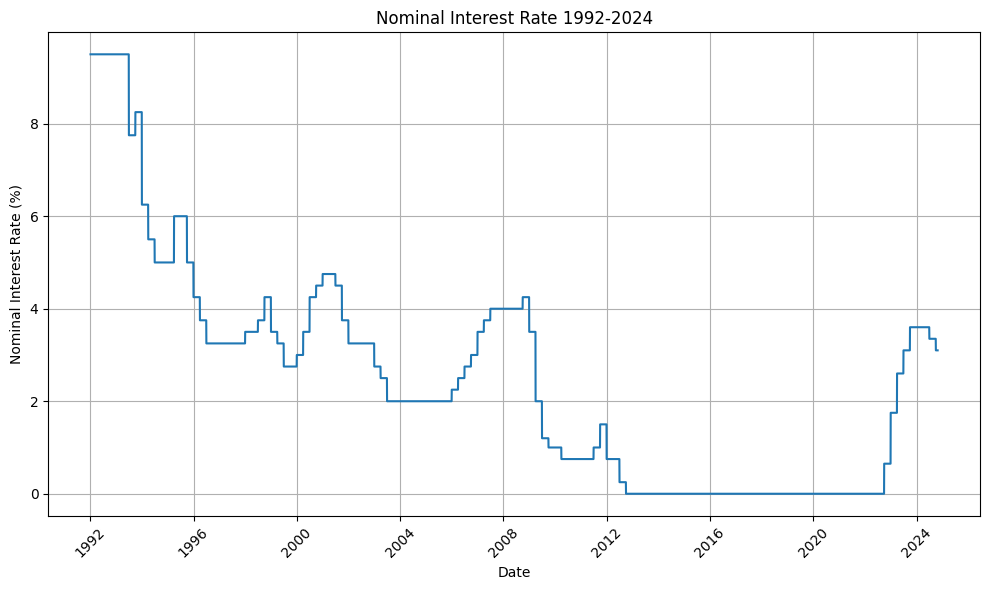

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(df_housing["date"], df_housing["nom_interest_rate%"], linestyle='-')
plt.title("Nominal Interest Rate 1992-2024")
plt.xlabel("Date")
plt.ylabel("Nominal Interest Rate (%)")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

## Read population dataset

In [ ]:
df_population = pd.read_excel("Population_by_area.xlsx", header=2)
df_population

# Se de faktiske kolonnenavne
print(df_population.columns.tolist())

['Region Hovedstaden', 1645825, 1648990, 1650985, 1660042, 1662285, 1665879, 1668564, 1678220, 1680271, 1684985, 1687071, 1697490, 1699387, 1702388, 1704043, 1713624, 1714589, 1718418, 1720152, 1729952, 1732068, 1735521, 1736889, 1747596, 1749405, 1753976, 1756068, 1766677, 1768125, 1772912, 1775479, 1786469, 1789174, 1793489, 1795211, 1806249, 1807404, 1811809, 1812168, 1821577, 1822659, 1826010, 1825952, 1835537, 1835562, 1839658, 1840357, 1848989, 1846023, 1847147, 1847289, 1854296, 1855084, 1856061, 1857783, 1866088, 1867948, 1872791, 1879191, 1889272, 1891871, 1898426, 1900006, 1910395, 1911067, 1916575, 1918855, 1929616, 1930793, 1936242, 1936735, 1946302, 1947212]


In [30]:

df_population.columns.tolist()

['Region Hovedstaden',
 1645825,
 1648990,
 1650985,
 1660042,
 1662285,
 1665879,
 1668564,
 1678220,
 1680271,
 1684985,
 1687071,
 1697490,
 1699387,
 1702388,
 1704043,
 1713624,
 1714589,
 1718418,
 1720152,
 1729952,
 1732068,
 1735521,
 1736889,
 1747596,
 1749405,
 1753976,
 1756068,
 1766677,
 1768125,
 1772912,
 1775479,
 1786469,
 1789174,
 1793489,
 1795211,
 1806249,
 1807404,
 1811809,
 1812168,
 1821577,
 1822659,
 1826010,
 1825952,
 1835537,
 1835562,
 1839658,
 1840357,
 1848989,
 1846023,
 1847147,
 1847289,
 1854296,
 1855084,
 1856061,
 1857783,
 1866088,
 1867948,
 1872791,
 1879191,
 1889272,
 1891871,
 1898426,
 1900006,
 1910395,
 1911067,
 1916575,
 1918855,
 1929616,
 1930793,
 1936242,
 1936735,
 1946302,
 1947212]

### make long format

In [31]:
# 1. Omdøb de første kolonner
df_population.columns = ['Municipality'] + list(df_population.columns[1:])

print(df_population.columns.tolist())
# 2. Tjek hvad der er i 'Municipality' kolonnen
print(df_population['Municipality'].unique())



['Municipality', 1645825, 1648990, 1650985, 1660042, 1662285, 1665879, 1668564, 1678220, 1680271, 1684985, 1687071, 1697490, 1699387, 1702388, 1704043, 1713624, 1714589, 1718418, 1720152, 1729952, 1732068, 1735521, 1736889, 1747596, 1749405, 1753976, 1756068, 1766677, 1768125, 1772912, 1775479, 1786469, 1789174, 1793489, 1795211, 1806249, 1807404, 1811809, 1812168, 1821577, 1822659, 1826010, 1825952, 1835537, 1835562, 1839658, 1840357, 1848989, 1846023, 1847147, 1847289, 1854296, 1855084, 1856061, 1857783, 1866088, 1867948, 1872791, 1879191, 1889272, 1891871, 1898426, 1900006, 1910395, 1911067, 1916575, 1918855, 1929616, 1930793, 1936242, 1936735, 1946302, 1947212]
<ArrowStringArray>
[      'København',   'Frederiksberg',          'Dragør',          'Tårnby',
     'Albertslund',        'Ballerup',         'Brøndby',        'Gentofte',
        'Gladsaxe',        'Glostrup',
 ...
   'Frederikshavn',        'Hjørring',      'Jammerbugt',            'Læsø',
   'Mariagerfjord',           'M

In [32]:
# Kvartal-kolonner 2008-2024
kvartal_cols = [c for c in df_population.columns if str(c).startswith(('2008','2009','2010','2011','2012','2013','2014','2015','2016','2017','2018','2019','2020','2021','2022','2023','2024'))]

#regions as defined by Statistics Denmark, excluding "Hele landet" and the regions themselves
regioner = ['Region Hovedstaden', 'Region Sjælland', 'Region Syddanmark', 'Region Midtjylland', 'Region Nordjylland']
exclude = ['Hele landet'] + regioner

# Split i regioner og kommuner
df_pop_regions = df_population[df_population['Municipality'].isin(regioner)][['Municipality'] + kvartal_cols]
df_pop_kommuner = df_population[~df_population['Municipality'].isin(exclude) & df_population['Municipality'].notna()][['Municipality'] + kvartal_cols]

# Smelt til long + aggreger til år
def pop_to_yearly(df, id_col='Municipality'):
    df_long = df.melt(id_vars=[id_col], var_name='quarter_str', value_name='population')
    df_long['year'] = df_long['quarter_str'].str[:4].astype(int)
    return df_long.groupby([id_col, 'year'])['population'].mean().reset_index()

df_pop_kommuner_yearly = pop_to_yearly(df_pop_kommuner)
df_pop_regions_yearly = pop_to_yearly(df_pop_regions)
region = { #map to same names as in income dataset
    'Region Hovedstaden': 'Capital Region',  # inkl. Bornholm
    'Region Sjælland': 'Zealand Region',                 # inkl. Other islands
    'Region Syddanmark': 'Southern Denmark',         # inkl. Fyn & islands
    'Region Midtjylland': 'Central Jutland',
    'Region Nordjylland': 'North Jutland'
}

df_pop_regions_yearly['Region'] = df_pop_regions_yearly['Municipality'].map(region)

print(df_pop_kommuner_yearly.head(10))
print(df_pop_regions_yearly.head())
print(len(df_pop_kommuner_yearly))

#map munipanci so København to Copenhagen and Vesthimmerlands = Vesthimmerland 
df_pop_kommuner_yearly["Municipality"] = df_pop_kommuner_yearly["Municipality"].replace({
    "København": "Copenhagen",
    "Vesthimmerlands": "Vesthimmerland"
})

# FØR merge
print("=== FØR ===")
print("Bornholm:")
print(df_pop_kommuner_yearly[df_pop_kommuner_yearly["Municipality"] == "Bornholm"]["population"].values)
print("Christiansø:")
print(df_pop_kommuner_yearly[df_pop_kommuner_yearly["Municipality"] == "Christiansø"]["population"].values)


#merge christiansø ind under bornholm 
df_pop_kommuner_yearly["Municipality"] = df_pop_kommuner_yearly["Municipality"].replace({"Christiansø": "Bornholm"})
# Summer Christiansø + Bornholm sammen (de har nu samme navn)
df_pop_kommuner_yearly = df_pop_kommuner_yearly.groupby(
    ["Municipality", "year"], as_index=False
)["population"].sum()

#check if the population number has changed correctly 

# EFTER merge
print("\n=== EFTER ===")
print("Bornholm (skal være større end før):")
print(df_pop_kommuner_yearly[df_pop_kommuner_yearly["Municipality"] == "Bornholm"]["population"].values)
print(df_pop_kommuner_yearly['Municipality'].nunique())

print(df_pop_kommuner_yearly.columns.tolist())
print(df_pop_kommuner_yearly.head())
#save df_pop_kommuner_yearly to csv
df_pop_kommuner_yearly.to_csv("pop_kommuner_yearly.csv", index=False)


Empty DataFrame
Columns: [Municipality, year, population]
Index: []
Empty DataFrame
Columns: [Municipality, year, population, Region]
Index: []
0
=== FØR ===
Bornholm:
[]
Christiansø:
[]

=== EFTER ===
Bornholm (skal være større end før):
[]
0
['Municipality', 'year', 'population']
Empty DataFrame
Columns: [Municipality, year, population]
Index: []


In [33]:
print(df_pop_kommuner_yearly["year"].unique())
print(df_pop_kommuner_yearly["year"].value_counts())

[]
Series([], Name: count, dtype: int64)


In [34]:
print(df_pop_regions_yearly["Region"].value_counts())
#print value counts for year and region in df_pop_regions_yearly i sorteret rækkefølge
print(df_pop_regions_yearly["year"].value_counts().sort_index())
print(df_pop_regions_yearly.columns.tolist())
print(df_pop_regions_yearly)

print(df_pop_regions_yearly["Region"].value_counts())

#drop municipality column from df_pop_regions_yearly
df_pop_regions_yearly = df_pop_regions_yearly.drop(columns=["Municipality"])

#read to csv
df_pop_regions_yearly.to_csv("pop_regions_yearly.csv", index=False)

Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)
['Municipality', 'year', 'population', 'Region']
Empty DataFrame
Columns: [Municipality, year, population, Region]
Index: []
Series([], Name: count, dtype: int64)


In [35]:
from collections import defaultdict

# now we need to map the municipalities to the regions, so we can merge with the income dataset
municipality_to_region = {
    "Capital Region": [
        "Copenhagen", "Frederiksberg", "Gentofte", "Gladsaxe", "Helsingør",
        "Hillerød", "Hvidovre", "Lyngby-Taarbæk", "Rødovre", "Ballerup",
        "Brøndby", "Dragør", "Egedal", "Fredensborg", "Frederikssund",
        "Furesø", "Gribskov", "Halsnæs", "Herlev", "Høje-Taastrup",
        "Hørsholm", "Ishøj", "Rudersdal", "Tårnby", "Vallensbæk",
        "Albertslund", "Allerød", "Glostrup", "Bornholm"
    ],
    "Zealand Region": [
        "Roskilde", "Holbæk", "Næstved", "Slagelse", "Køge",
        "Guldborgsund", "Vordingborg", "Kalundborg", "Ringsted",
        "Sorø", "Lejre", "Stevns", "Solrød", "Faxe", "Odsherred",
        "Greve", "Lolland",
    ],
    "Central Jutland": [
        "Aarhus", "Randers", "Viborg", "Silkeborg", "Herning",
        "Horsens", "Skanderborg", "Holstebro", "Skive",
        "Ringkøbing-Skjern", "Favrskov", "Hedensted",
        "Syddjurs", "Ikast-Brande", "Norddjurs", "Struer",
        "Odder", "Lemvig", "Samsø"
    ],
    "North Jutland": [
        "Aalborg", "Hjørring", "Frederikshavn", "Thisted",
        "Mariagerfjord", "Jammerbugt", "Vesthimmerland", 
        "Brønderslev", "Rebild", "Morsø", "Læsø"
    ],
    "Southern Denmark": [
        "Odense", "Esbjerg", "Vejle", "Kolding", "Sønderborg",
        "Aabenraa", "Svendborg", "Haderslev", "Faaborg-Midtfyn",
        "Varde", "Fredericia", "Vejen", "Assens", "Tønder",
        "Middelfart", "Nyborg", "Nordfyns", "Billund",
        "Kerteminde", "Langeland", "Ærø", "Fanø"
    ]
}

#tjek det hele passer:
# Vend dict om: kommune -> region
muni_to_region = {}
for region, munis in municipality_to_region.items():
    for muni in munis:
        muni_to_region[muni] = region

# Tilføj region-kolonne til kommuner
df_pop_kommuner_yearly["Region"] = df_pop_kommuner_yearly["Municipality"].map(muni_to_region)

# Tjek at ingen kommuner mangler en region
missing = df_pop_kommuner_yearly[df_pop_kommuner_yearly["Region"].isna()]["Municipality"].unique()
print(f"Kommuner uden region: {missing}")  # skal være tom

# Tjek at kommuner summer op til regioner
kommuner_sum = df_pop_kommuner_yearly.groupby(["Region", "year"])["population"].sum().reset_index()
kommuner_sum = kommuner_sum.rename(columns={"population": "pop_fra_kommuner"})

sammenlign = kommuner_sum.merge(df_pop_regions_yearly, on=["Region", "year"])
sammenlign["forskel"] = sammenlign["pop_fra_kommuner"] - sammenlign["population"]
sammenlign["forskel_%"] = (sammenlign["forskel"] / sammenlign["population"] * 100).round(2)

print(sammenlign[["Region", "year", "pop_fra_kommuner", "population", "forskel_%"]].head(20))

Kommuner uden region: <ArrowStringArray>
[]
Length: 0, dtype: str
Empty DataFrame
Columns: [Region, year, pop_fra_kommuner, population, forskel_%]
Index: []


### PASSER!

In [36]:
df_pop_kommuner_yearly.to_csv("pop_kommuner_yearly.csv", index=False)


In [37]:
# Hvilke cities ender i "Other islands"?
print(len(df_housing["city"].unique()))
missing_cities = df_housing[df_housing["city"].apply(get_region) == "Other islands"]["city"].unique()
print(len(missing_cities))
print(missing_cities)
df_housing["area"].nunique()

629


NameError: name 'get_region' is not defined

## Read income dataset

In [ ]:
df_income_region = pd.read_csv("income_region_long.csv")
df_income_municipality = pd.read_csv("income_muni_long.csv")

print(df_income_region["Region"].unique())
print(df_income_municipality["Municipality"].nunique())
print(df_pop_kommuner_yearly["Municipality"].nunique())
print(df_income_region.columns.tolist())


['Capital Region' 'Central Jutland' 'North Jutland' 'Southern Denmark'
 'Zealand Region']
98
99
['Region', 'year', 'income']


## Check if they are the same 

In [ ]:
for muni in df_pop_kommuner_yearly["Municipality"].unique():
    if muni not in df_income_municipality["Municipality"].unique():
        print(muni)

for muni in df_income_municipality["Municipality"].unique():
    if muni not in df_pop_kommuner_yearly["Municipality"].unique():
        print(muni)

## Read housing 

In [ ]:
#tjek hvilke kommuner der mangler
alle_kommuner = set(muni_to_region.keys())  # fra din dict = 98 kommuner
kommuner_i_housing = set(v for v in zip_to_muni.values() if v is not None)


# 1. Fix navne FØRST
zip_to_muni_clean = {
    k: (v.replace("København", "Copenhagen")
         .replace("Vesthimmerlands", "Vesthimmerland") if v else None)
    for k, v in zip_to_muni.items()
}

# 2. Tjek manglende EFTER fix
kommuner_i_housing = set(v for v in zip_to_muni_clean.values() if v is not None)
print("Mangler i housing:")
print(alle_kommuner - kommuner_i_housing)

Mangler i housing:
{'Rødovre', 'Tårnby', 'Sorø', 'Herlev', 'Mariagerfjord', 'Glostrup', 'Hvidovre'}


In [ ]:
print(df_housing["zip_code"].dtype)
print(df_housing["zip_code"].head())

int16
0    8382
1    4400
2    9260
3    8000
4    8600
Name: zip_code, dtype: int16


### Check for missing

In [ ]:
# Konverter zip_code til string i df_housing så vi kan tjekke mod vores dict
df_housing["zip_code"] = df_housing["zip_code"].astype(int)

# Og sørg for zip_to_muni_clean også har string keys (det burde den allerede)
print(type(list(zip_to_muni_clean.keys())[0]))  # skal printe <class 'str'>
print(type(df_housing["zip_code"].iloc[0]))  # skal også printe <class 'str'>

<class 'numpy.int16'>
<class 'numpy.int64'>


In [ ]:
# Tjek hvilke postnumre der faktisk er i df_housing for disse kommuner
mistanke = ["Rødovre", "Tårnby", "Herlev", "Hvidovre", "Glostrup", "Sorø", "Mariagerfjord"]

# Se hvad zip_to_muni_clean returnerer for relevante postnumre
for zip_code, muni in zip_to_muni_clean.items():
    if muni in mistanke:
        print(zip_code, "->", muni)

# Hvilke zip codes burde give Rødovre, Hvidovre etc?
# Tjek direkte hvad API'et returnerede for de relevante postnumre
rodovre_zips = [2610, 2620, 2630, 2650, 2680]
taarnby_zips = [2770, 2791, 2792, 2793, 2794, 2795, 2796, 2797, 2798, 2799]
herlev_zips = [2730, 2740, 2750, 2760, 2770, 2780, 2791, 2792, 2793, 2794, 2795, 2796, 2797, 2798, 2799]
hvidovre_zips = [2650, 2660, 2670, 2680, 2690]
glostrup_zips = [2600, 2610, 2620, 2630, 2640, 2650, 2660, 2670, 2680, 2690]
sorø_zips = [4180, 4190, 4200, 4210, 4220, 4230, 4240, 4250, 4260, 4270, 4280, 4290]
mariagerfjord_zips = [9500, 9550, 9560, 9574, 9580, 9592, 9600]

for z in rodovre_zips + taarnby_zips + herlev_zips + hvidovre_zips + glostrup_zips:
    print(f"{z} -> {zip_to_muni_clean.get(z, 'IKKE I DATASÆTTET')}")

#print dem der er i datasættet

for zip in df_housing["zip_code"].unique():
    if zip in rodovre_zips + taarnby_zips + herlev_zips + hvidovre_zips + glostrup_zips+sorø_zips+mariagerfjord_zips:
        print(f"{zip} -> {zip_to_muni_clean.get(zip, 'IKKE I DATASÆTTET')}")


2610 -> Copenhagen
2620 -> Brøndby
2630 -> Albertslund
2650 -> Brøndby
2680 -> Solrød
2770 -> Copenhagen
2791 -> Dragør
2792 -> IKKE I DATASÆTTET
2793 -> IKKE I DATASÆTTET
2794 -> IKKE I DATASÆTTET
2795 -> IKKE I DATASÆTTET
2796 -> IKKE I DATASÆTTET
2797 -> IKKE I DATASÆTTET
2798 -> IKKE I DATASÆTTET
2799 -> IKKE I DATASÆTTET
2730 -> Ballerup
2740 -> Ballerup
2750 -> Ballerup
2760 -> Ballerup
2770 -> Copenhagen
2780 -> IKKE I DATASÆTTET
2791 -> Dragør
2792 -> IKKE I DATASÆTTET
2793 -> IKKE I DATASÆTTET
2794 -> IKKE I DATASÆTTET
2795 -> IKKE I DATASÆTTET
2796 -> IKKE I DATASÆTTET
2797 -> IKKE I DATASÆTTET
2798 -> IKKE I DATASÆTTET
2799 -> IKKE I DATASÆTTET
2650 -> Brøndby
2660 -> Brøndby
2670 -> Greve
2680 -> Solrød
2690 -> Greve
2600 -> Brøndby
2610 -> Copenhagen
2620 -> Brøndby
2630 -> Albertslund
2640 -> Høje-Taastrup
2650 -> Brøndby
2660 -> Brøndby
2670 -> Greve
2680 -> Solrød
2690 -> Greve
4200 -> Kalundborg
2740 -> Ballerup
2680 -> Solrød
2750 -> Ballerup
2600 -> Brøndby
2610 -> C

In [ ]:
# Manuel korrektion for fejlmappede postnumre
zip_corrections = {
    2610: "Rødovre",
    2650: "Hvidovre",
    2660: "Brøndby",      # denne er ok
    2730: "Herlev",
    2740: "Glostrup",
    2750: "Ballerup",     # tjek denne
    2760: "Glostrup",
    9500: "Mariagerfjord",
    9550: "Mariagerfjord",
    9560: "Mariagerfjord",
    9574: "Mariagerfjord",
    9580: "Mariagerfjord",
    9592: "Mariagerfjord",
    4180: "Sorø",
    4190: "Sorø",
}
# Tårnby postnumre er 2770 og 2791
print(zip_to_muni_clean.get(2770))
print(zip_to_muni_clean.get(2791))

# Hvad er der i housing?
print(df_housing[df_housing["zip_code"] == 2770]["city"].unique())
print(df_housing[df_housing["zip_code"] == 2791]["city"].unique())
zip_corrections[2770] = "Tårnby"

zip_to_muni_clean.update(zip_corrections)

df_housing["municipality"] = df_housing["zip_code"].map(zip_to_muni_clean)
df_housing["region"] = df_housing["municipality"].map(muni_to_region)

kommuner_i_housing = set(df_housing["municipality"].dropna().unique())
print("Mangler stadig:")
print(alle_kommuner - kommuner_i_housing)

# Opdater zip_to_muni_clean med korrektionerne
zip_to_muni_clean.update(zip_corrections)

# Kør mapping igen
df_housing["municipality"] = df_housing["zip_code"].map(zip_to_muni_clean)
df_housing["region"] = df_housing["municipality"].map(muni_to_region)

kommuner_i_housing = set(df_housing["municipality"].dropna().unique())
print("Mangler stadig:")
print(alle_kommuner - kommuner_i_housing)

Copenhagen
Dragør
['Kastrup']
['Dragør']
Mangler stadig:
set()
Mangler stadig:
set()


In [ ]:
# Hvilke zip codes er faktisk i df_housing der starter med 26 eller 27?
zips_i_housing = df_housing["zip_code"].unique()
print(sorted([z for z in zips_i_housing if 2600 <= z <= 2799]))

[2600, 2605, 2610, 2620, 2625, 2630, 2635, 2640, 2650, 2660, 2665, 2670, 2680, 2690, 2700, 2720, 2730, 2740, 2750, 2760, 2765, 2770, 2791]


In [ ]:
import json

with open("zip_to_muni_clean.json", "w") as f:
    # Konverter int keys til string (JSON kræver string keys)
    json.dump({str(k): v for k, v in zip_to_muni_clean.items()}, f, ensure_ascii=False)

# Indlæs igen senere med:
# with open("zip_to_muni_clean.json") as f:
#     zip_to_muni_clean = {int(k): v for k, v in json.load(f).items()}

In [ ]:
print(df_housing.columns.tolist())
print(df_housing.head())

['date', 'quarter', 'house_id', 'house_type', 'sales_type', 'year_build', 'purchase_price', '%_change_between_offer_and_purchase', 'no_rooms', 'sqm', 'sqm_price', 'address', 'zip_code', 'city', 'area', 'region', 'nom_interest_rate%', 'dk_ann_infl_rate%', 'yield_on_mortgage_credit_bonds%', 'municipality', 'Municipality', 'Region']
        date  quarter  house_id   house_type    sales_type  year_build  \
0 2024-10-26      219         0        Villa  regular_sale        1974   
1 2024-10-26      219         2  Summerhouse  regular_sale        1956   
2 2024-10-26      219         1         Farm  regular_sale        1955   
3 2024-10-25      219         3    Apartment   family_sale        1945   
4 2024-10-25      219         4        Villa  regular_sale        1967   

   purchase_price  %_change_between_offer_and_purchase  no_rooms    sqm  ...  \
0         4350000                                  0.0         5  215.0  ...   
1          450000                                  0.0         

In [ ]:
print(df_housing["region"].unique())
print(df_housing["region"].value_counts())
print(df_housing["municipality"].unique())
print(df_housing["municipality"].value_counts())

#print rækker uden region eller municipality
print(len(df_housing[df_housing["region"].isna()]))
print(len(df_housing[df_housing["municipality"].isna()]))

['Central Jutland' 'Zealand Region' 'North Jutland' 'Southern Denmark'
 'Capital Region' nan]
region
Capital Region      369853
Central Jutland     360019
Southern Denmark    349711
Zealand Region      243658
North Jutland       183280
Name: count, dtype: int64
['Favrskov' 'Kalundborg' 'Rebild' 'Aarhus' 'Silkeborg' 'Odder' 'Vejle'
 'Haderslev' 'Varde' 'Glostrup' 'Solrød' 'Copenhagen' 'Herning'
 'Frederiksberg' 'Fredericia' 'Helsingør' 'Slagelse' 'Holstebro' 'Allerød'
 'Frederikssund' 'Ringkøbing-Skjern' 'Faxe' 'Holbæk' 'Nordfyns' 'Køge'
 'Vesthimmerland' 'Gentofte' 'Ballerup' 'Syddjurs' 'Kolding' 'Brøndby'
 'Frederikshavn' 'Vejen' 'Rødovre' 'Guldborgsund' 'Aalborg' 'Roskilde'
 'Odense' 'Høje-Taastrup' 'Langeland' 'Furesø' 'Thisted' 'Hedensted'
 'Faaborg-Midtfyn' 'Stevns' 'Kerteminde' 'Esbjerg' 'Middelfart'
 'Norddjurs' 'Svendborg' 'Randers' 'Brønderslev' 'Tønder' 'Dragør'
 'Næstved' 'Bornholm' 'Morsø' 'Gribskov' 'Jammerbugt' 'Fredensborg'
 'Odsherred' 'Lolland' 'Aabenraa' 'Halsnæs' 'Ny

In [ ]:
#tjek hvilke der mangler
print(df_housing[df_housing["municipality"].isna()][["zip_code", "city", "area"]].drop_duplicates())

      zip_code     city           area
1386      6330  Padborg  South jutland


In [ ]:
zip_to_muni_clean[6330] = "Aabenraa"

df_housing["municipality"] = df_housing["zip_code"].map(zip_to_muni_clean)
df_housing["region"] = df_housing["municipality"].map(muni_to_region)

print(len(df_housing[df_housing["municipality"].isna()]))  # skal være 0
print(len(df_housing[df_housing["region"].isna()]))        # skal være 0

0
0


In [ ]:

print(df_housing.columns.tolist())

#lav til csv
df_housing.to_csv("housing_with_muni_region.csv", index=False)


['date', 'quarter', 'house_id', 'house_type', 'sales_type', 'year_build', 'purchase_price', '%_change_between_offer_and_purchase', 'no_rooms', 'sqm', 'sqm_price', 'address', 'zip_code', 'area', 'region', 'nom_interest_rate%', 'dk_ann_infl_rate%', 'yield_on_mortgage_credit_bonds%', 'municipality']


KeyboardInterrupt: 

## check if len fits

In [ ]:
print(len(df_housing))

df_old = pd.read_parquet("DKHousingPrices.parquet", engine="fastparquet")
print(len(df_old))

1507908
1507908


In [ ]:
# Konverter zip_code til string
df_housing["zip_code"] = df_housing["zip_code"].astype(str)

# Tilføj kommune og region
df_housing["Municipality"] = df_housing["zip_code"].map(zip_to_muni_clean)
df_housing["Region"] = df_housing["Municipality"].map(muni_to_region)


print(f"Rækker uden kommune: {df_housing['Municipality'].isna().sum()}")
print(f"Rækker uden region:  {df_housing['Region'].isna().sum()}")

Rækker uden kommune: 1507908
Rækker uden region:  1507908


In [ ]:
for muni in alle_kommuner:
    if muni not in kommuner_i_housing:
        print(muni)


Hvidovre
Vesthimmerland
Herlev
Mariagerfjord
Glostrup
Rødovre
Copenhagen
Tårnby
Sorø


In [ ]:
for muni in kommuner_i_housing:
    if muni not in alle_kommuner:
        print(muni)

København
Vesthimmerlands


## make new housing

In [ ]:
df_housing["year"] = pd.to_datetime(df_housing["date"]).dt.year

agg_dict = {
    "purchase_price": ["mean", "median"],
    "sqm_price": ["mean", "median"],
    "sqm": "mean",
    "no_rooms": "mean",
    "%_change_between_offer_and_purchase": "mean",
    "nom_interest_rate%": "mean",
    "dk_ann_infl_rate%": "mean",
    "yield_on_mortgage_credit_bonds%": "mean",
    "house_id": "count"
}

# Kommune-niveau
df_housing_muni = df_housing.groupby(["municipality", "region", "year"]).agg(agg_dict).reset_index()

# Flatten kolonnenavne: "purchase_price_mean", "house_id_count" osv.
df_housing_muni.columns = ["_".join(col).strip("_") for col in df_housing_muni.columns]
df_housing_muni = df_housing_muni.rename(columns={"house_id_count": "no_sales"})

# Region-niveau
df_housing_region = df_housing.groupby(["region", "year"]).agg(agg_dict).reset_index()
df_housing_region.columns = ["_".join(col).strip("_") for col in df_housing_region.columns]
df_housing_region = df_housing_region.rename(columns={"house_id_count": "no_sales"})

#sorter year <2008 fra
df_housing_muni = df_housing_muni[df_housing_muni["year"] >= 2008]
df_housing_region = df_housing_region[df_housing_region["year"] >= 2008]
print(df_housing_muni.columns.tolist())
print(df_housing_muni.shape)
print(df_housing_region.shape)


['municipality', 'region', 'year', 'purchase_price_mean', 'purchase_price_median', 'sqm_price_mean', 'sqm_price_median', 'sqm_mean', 'no_rooms_mean', '%_change_between_offer_and_purchase_mean', 'nom_interest_rate%_mean', 'dk_ann_infl_rate%_mean', 'yield_on_mortgage_credit_bonds%_mean', 'no_sales']
(1666, 14)
(85, 13)


3230 rækker i muni: ~98 kommuner × ~33 år (1992-2024) = ~3234 
165 rækker i region: 5 regioner × 33 år = 165 

In [ ]:
print(df_housing_muni.head())
print(df_housing_region.head())

  municipality            region  year  purchase_price_mean  \
0     Aabenraa  Southern Denmark  1992         8.054022e+05   
1     Aabenraa  Southern Denmark  1993         1.006394e+06   
2     Aabenraa  Southern Denmark  1994         6.516751e+05   
3     Aabenraa  Southern Denmark  1995         8.655239e+05   
4     Aabenraa  Southern Denmark  1996         8.337873e+05   

   purchase_price_median  sqm_price_mean  sqm_price_median    sqm_mean  \
0               550000.0     6952.213379       3894.031738  143.443970   
1               650000.0     8704.012695       4290.540527  148.389114   
2               550000.0     4548.906250       4200.000000  150.988770   
3               604000.0     7015.916992       4342.985352  149.229004   
4               595000.0     7205.340332       4508.064453  146.347961   

   no_rooms_mean  %_change_between_offer_and_purchase_mean  \
0       4.706897                                       0.0   
1       4.744770                                    

### read to csv

In [ ]:
# Gem til CSV
df_housing_muni.to_csv("housing_municipality_yearly.csv", index=False)
df_housing_region.to_csv("housing_region_yearly.csv", index=False)

### tjek - alt giver mening!

In [ ]:
# 1. Tjek år-range
print(df_housing_muni["year"].min(), df_housing_muni["year"].max())
print(df_housing_region["year"].min(), df_housing_region["year"].max())

# 2. Tjek antal unikke kommuner og regioner
print(df_housing_muni["municipality"].nunique())   # skal være 98
print(df_housing_region["region"].nunique())       # skal være 5

# 3. Tjek at region-gennemsnit giver mening ift. kommune-gennemsnit
# Tag et år og en region og sammenlign
year = 2015
region = "Capital Region"

muni_mean = df_housing_muni[
    (df_housing_muni["region"] == region) & 
    (df_housing_muni["year"] == year)
]["purchase_price_mean"].mean()

region_mean = df_housing_region[
    (df_housing_region["region"] == region) & 
    (df_housing_region["year"] == year)
]["purchase_price_mean"].values[0]

print(f"\nCapital Region 2015:")
print(f"Gennemsnit af kommuner:  {muni_mean:,.0f}")
print(f"Direkte region-gennemsnit: {region_mean:,.0f}")
#tjek for alle regioner 
region = "Zealand Region"
muni_mean = df_housing_muni[
    (df_housing_muni["region"] == region) & 
    (df_housing_muni["year"] == year)
]["purchase_price_mean"].mean()

region_mean = df_housing_region[
    (df_housing_region["region"] == region) & 
    (df_housing_region["year"] == year)
]["purchase_price_mean"].values[0]

print(f"\n{region} 2015:")
print(f"Gennemsnit af kommuner:  {muni_mean:,.0f}")
print(f"Direkte region-gennemsnit: {region_mean:,.0f}")


# Tjek også et par kommuner giver mening - dyreste kommuner i Capital Region i 2015
print(df_housing_muni[
    (df_housing_muni["year"] == 2015) & 
    (df_housing_muni["region"] == "Capital Region")
][["municipality", "purchase_price_mean", "no_sales"]].sort_values("purchase_price_mean", ascending=False).head(10))

# Disse vil ikke være identiske (kommune-mean vægter alle kommuner ens,
# region-mean vægter alle salg ens) men skal være i samme boldpark

# 4. Tjek ingen NaN
print(df_housing_muni.isna().sum())
print(df_housing_region.isna().sum())

2008 2024
2008 2024
98
5

Capital Region 2015:
Gennemsnit af kommuner:  2,766,167
Direkte region-gennemsnit: 2,873,803

Zealand Region 2015:
Gennemsnit af kommuner:  1,564,464
Direkte region-gennemsnit: 1,506,645
        municipality  purchase_price_mean  no_sales
1471        Hørsholm         5.819128e+06       167
1867  Lyngby-Taarbæk         4.578257e+06       440
712    Frederiksberg         4.538200e+06       177
844         Gentofte         4.330651e+06      1022
2428       Rudersdal         3.697186e+06        97
382       Copenhagen         3.404143e+06      4674
221         Ballerup         3.244409e+06       387
415           Dragør         3.242082e+06       229
877         Gladsaxe         3.095343e+06       167
811           Furesø         3.020565e+06       486
municipality                                0
region                                      0
year                                        0
purchase_price_mean                         0
purchase_price_median          

In [ ]:
# Tjek alle regioner og alle år
results = []

for region in df_housing_region["region"].unique():
    for year in df_housing_region["year"].unique():
        muni_mean = df_housing_muni[
            (df_housing_muni["region"] == region) & 
            (df_housing_muni["year"] == year)
        ]["purchase_price_mean"].mean()
        
        region_row = df_housing_region[
            (df_housing_region["region"] == region) & 
            (df_housing_region["year"] == year)
        ]
        
        if len(region_row) == 0:
            continue
            
        region_mean = region_row["purchase_price_mean"].values[0]
        forskel_pct = abs(muni_mean - region_mean) / region_mean * 100
        
        results.append({
            "region": region,
            "year": year,
            "muni_mean": round(muni_mean),
            "region_mean": round(region_mean),
            "forskel_%": round(forskel_pct, 1)
        })

df_check = pd.DataFrame(results).sort_values(["region", "year"])
print(df_check.to_string(index=False))

# Flagér hvis forskel er over 20% (kunne indikere fejl)
store_afvigelser = df_check[df_check["forskel_%"] > 20]
if len(store_afvigelser) > 0:
    print("\n⚠️ Store afvigelser (>20%):")
    print(store_afvigelser.to_string(index=False))
else:
    print("\n✅ Ingen afvigelser over 20%")

          region  year  muni_mean  region_mean  forskel_%
  Capital Region  2008    2729963      2682002        1.8
  Capital Region  2009    2387718      2455395        2.8
  Capital Region  2010    2566032      2599042        1.3
  Capital Region  2011    2495136      2557964        2.5
  Capital Region  2012    2432683      2513142        3.2
  Capital Region  2013    2557784      2685808        4.8
  Capital Region  2014    2653887      2785699        4.7
  Capital Region  2015    2766167      2873803        3.7
  Capital Region  2016    2926451      3034356        3.6
  Capital Region  2017    3087748      3150039        2.0
  Capital Region  2018    3206100      3233211        0.8
  Capital Region  2019    3257112      3288494        1.0
  Capital Region  2020    3612476      3641920        0.8
  Capital Region  2021    3955243      3946922        0.2
  Capital Region  2022    3854341      3736991        3.1
  Capital Region  2023    3741707      3738086        0.1
  Capital Regi